# Loan Approval Prediction

Supervised classification pipeline covering missing-value handling, categorical encoding, scaling, class imbalance, model comparison, threshold analysis, and business-oriented interpretation.

**Models:** Logistic Regression, Decision Tree, Random Forest.

**Primary metrics:** Precision, Recall, F1, ROC-AUC. The deployment threshold is selected using validation data rather than the test set.


In [1]:
# Install if needed:
# %pip install pandas numpy scikit-learn imbalanced-learn matplotlib seaborn

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)

RANDOM_STATE = 42
DATA_PATH = '/mnt/data/loan_prediction.csv'  # uploaded dataset
TARGET = 'Loan_Status'            # <-- change if your target has another name


In [2]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Load data
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
display(df.head())
display(df.info())

# Standardize common target encodings when applicable.
if df[TARGET].dtype == 'object':
    target_map = {'Y': 1, 'N': 0, 'Yes': 1, 'No': 0, 'Approved': 1, 'Rejected': 0}
    mapped = df[TARGET].map(target_map)
    if mapped.notna().all():
        df[TARGET] = mapped.astype(int)

print('\nTarget distribution:')
print(df[TARGET].value_counts(dropna=False))
print('\nTarget rate:')
print(df[TARGET].mean())


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/loan_prediction.csv'

In [5]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles in current folder:")
print(os.listdir())

Current folder:
c:\Users\ranji\OneDrive\Desktop\Loan-Approval-Prediction

Files in current folder:
['data', 'loan_approval_prediction.ipynb', 'loan_approval_short_report.docx']


In [6]:
import pandas as pd

# Path to CSV file
DATA_PATH = "loan_prediction.csv"

# Load data
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())

print("\nDataset information:")
df.info()

FileNotFoundError: [Errno 2] No such file or directory: 'loan_prediction.csv'

In [7]:
import os
import pandas as pd

DATA_PATH = r"C:\Users\ranji\OneDrive\Desktop\Loan-Approval-Prediction\loan_prediction.csv"

print("File exists:", os.path.exists(DATA_PATH))
print("File path:", DATA_PATH)

File exists: False
File path: C:\Users\ranji\OneDrive\Desktop\Loan-Approval-Prediction\loan_prediction.csv


In [9]:
import os

folder = r"C:\Users\ranji\OneDrive\Desktop\Loan-Approval-Prediction"

print("Folder exists:", os.path.exists(folder))
print("\nFiles found:")

for file in os.listdir(folder):
    print(repr(file))

Folder exists: True

Files found:
'data'
'loan_approval_prediction.ipynb'
'loan_approval_short_report.docx'


In [ ]:
DATA_PATH = r"C:\Users\ranji\OneDrive\Desktop\Loan-Approval-Prediction\data\loan_prediction.csv"

In [10]:
import pandas as pd

DATA_PATH = r"C:\Users\ranji\OneDrive\Desktop\Loan-Approval-Prediction\data\loan_prediction.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())

print("\nDataset information:")
df.info()

Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [11]:
# Basic data-quality checks
missing = (df.isna().mean() * 100).sort_values(ascending=False)
display(pd.DataFrame({'missing_pct': missing}).head(20))

# Remove rows with missing target; target imputation is generally inappropriate for this task.
df = df.dropna(subset=[TARGET]).copy()

X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

# A validation split is used only for threshold selection/model diagnostics.
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=RANDOM_STATE
)

print('Train:', X_train.shape, 'Validation:', X_valid.shape, 'Test:', X_test.shape)


,missing_pct
Credit_History,8.143322
Self_Employed,5.211726
LoanAmount,3.583062
Dependents,2.442997
Loan_Amount_Term,2.280130
Gender,2.117264
Married,0.488599
Education,0.000000
Loan_ID,0.000000
CoapplicantIncome,0.000000


ValueError: invalid literal for int() with base 10: 'Y'

In [13]:
y = df[TARGET].map({'Y': 1, 'N': 0})

In [12]:
# Remove rows with missing target
df = df.dropna(subset=[TARGET]).copy()

# Separate features and target
X = df.drop(columns=[TARGET])

# Convert target: Y = 1, N = 0
y = df[TARGET].map({'Y': 1, 'N': 0})

# Check for any values that were not converted
print("Target values:")
print(y.value_counts(dropna=False))

# Remove rows if target contains unexpected values
valid = y.notna()
X = X.loc[valid].copy()
y = y.loc[valid].astype(int)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Target values:
Loan_Status
1    422
0    192
Name: count, dtype: int64
X_train shape: (491, 12)
X_test shape: (123, 12)
y_train shape: (491,)
y_test shape: (123,)


In [14]:
# Identify numeric/categorical columns and build preprocessing.
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_cols),
    ('cat', categorical_pipe, categorical_cols)
], remainder='drop')

print('Numeric columns:', numeric_cols)
print('Categorical columns:', categorical_cols)


Numeric columns: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
Categorical columns: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']


## Imbalance strategy

The primary comparison below uses **class weights**. This keeps the preprocessing pipeline simple and avoids synthetic observations after one-hot encoding. `class_weight='balanced'` increases the penalty for errors on the minority class. If the dataset has a particularly severe imbalance, SMOTE can be added after preprocessing, but it should be applied **only to training folds**, never before the train/test split.


In [15]:
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE
    ),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced', max_depth=5, min_samples_leaf=10,
        random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=400, class_weight='balanced', min_samples_leaf=5,
        random_state=RANDOM_STATE, n_jobs=-1
    )
}

pipelines = {
    name: Pipeline([('preprocess', preprocessor), ('model', model)])
    for name, model in models.items()
}

def evaluate_at_threshold(y_true, prob, threshold=0.5):
    pred = (prob >= threshold).astype(int)
    return {
        'Precision': precision_score(y_true, pred, zero_division=0),
        'Recall': recall_score(y_true, pred, zero_division=0),
        'F1': f1_score(y_true, pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, prob)
    }

results = []
valid_probs = {}
test_probs = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    p_valid = pipe.predict_proba(X_valid)[:, 1]
    p_test = pipe.predict_proba(X_test)[:, 1]
    valid_probs[name] = p_valid
    test_probs[name] = p_test
    row = evaluate_at_threshold(y_valid, p_valid, threshold=0.5)
    row['Model'] = name
    results.append(row)

results_df = pd.DataFrame(results).set_index('Model').sort_values('F1', ascending=False)
display(results_df.round(3))


NameError: name 'X_valid' is not defined

In [16]:
from sklearn.model_selection import train_test_split

# First split: 80% training, 20% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

# Second split: temporary data into 10% validation and 10% test
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print("Training:", X_train.shape)
print("Validation:", X_valid.shape)
print("Test:", X_test.shape)

print("\nTarget distributions:")
print("Train:")
print(y_train.value_counts(normalize=True))

print("\nValidation:")
print(y_valid.value_counts(normalize=True))

print("\nTest:")
print(y_test.value_counts(normalize=True))

Training: (491, 12)
Validation: (61, 12)
Test: (62, 12)

Target distributions:
Train:
Loan_Status
1    0.686354
0    0.313646
Name: proportion, dtype: float64

Validation:
Loan_Status
1    0.688525
0    0.311475
Name: proportion, dtype: float64

Test:
Loan_Status
1    0.693548
0    0.306452
Name: proportion, dtype: float64


In [17]:
valid_probs = {}
test_probs = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)

    p_valid = pipe.predict_proba(X_valid)[:, 1]
    p_test = pipe.predict_proba(X_test)[:, 1]

    valid_probs[name] = p_valid
    test_probs[name] = p_test

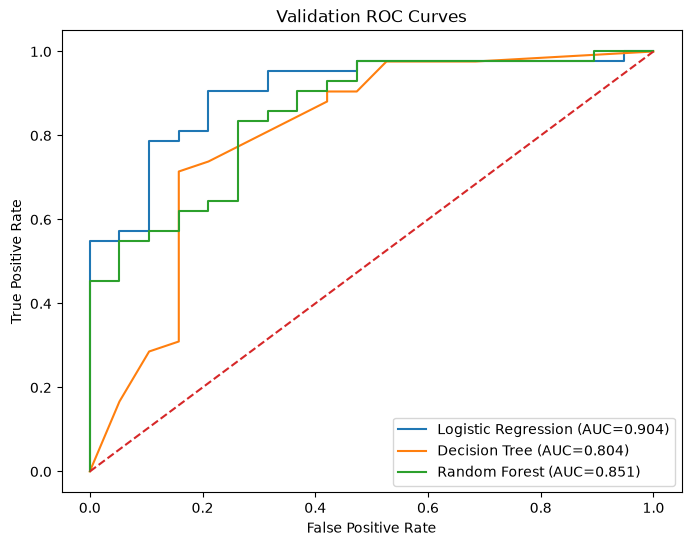

In [18]:
# ROC curves on validation data
plt.figure(figsize=(8, 6))
for name, prob in valid_probs.items():
    fpr, tpr, _ = roc_curve(y_valid, prob)
    auc = roc_auc_score(y_valid, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Validation ROC Curves')
plt.legend()
plt.show()


# Loan Approval Prediction

## Objective

The objective of this project is to build a machine learning model
that predicts whether a loan application will be approved or rejected.

The project focuses on:

- Data preprocessing
- Missing value handling
- Categorical variable encoding
- Feature scaling
- Class imbalance handling
- Model comparison
- Model evaluation
- Threshold selection
- Business interpretation

## Threshold selection

A 0.50 cutoff is not automatically appropriate for lending. Lowering the threshold generally increases recall (more applicants predicted as approvable) but can reduce precision (more false approvals). Raising it generally does the reverse. Select the threshold using business costs and validation data, then lock it before evaluating once on the test set.


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

ModuleNotFoundError: No module named 'seaborn'

In [21]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [24]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [25]:
df.shape

(614, 13)

In [26]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [28]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [29]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [30]:
df["Loan_Status"].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [31]:
df["Loan_Status"].value_counts(normalize=True) * 100

Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64

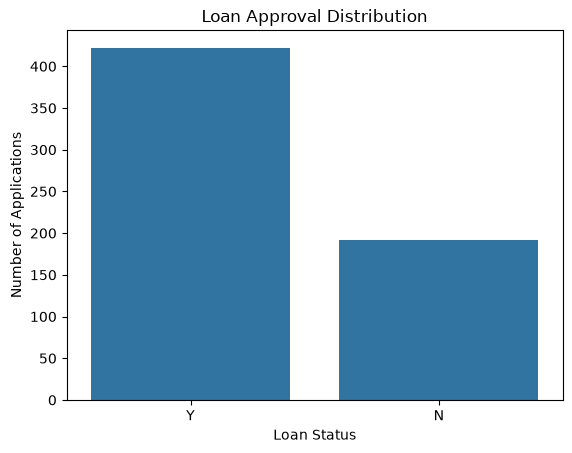

In [32]:
sns.countplot(x="Loan_Status", data=df)

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")

plt.show()

In [37]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [38]:
df["Loan_Status"] = df["Loan_Status"].map({
    "Y": 1,
    "N": 0
})

In [39]:
df["Loan_Status"].value_counts()

Loan_Status
1    422
0    192
Name: count, dtype: int64

In [40]:
X = df.drop("Loan_Status", axis=1)

y = df["Loan_Status"]

In [41]:
numeric_cols = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_cols = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

Categorical columns:
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']


In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [45]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    stratify=y_train,
    random_state=42
)

In [46]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [47]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [48]:
preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_cols
    ),

    (
        "categorical",
        categorical_pipeline,
        categorical_cols
    )
])

In [49]:
class_weight="balanced"

In [50]:
logistic_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),

    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        )
    )
])

In [51]:
logistic_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Gender','Married','Dependents',...,'Loan_Amount_Term','Credit_History', 'Property_Area']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``

In [52]:
logistic_prob = logistic_model.predict_proba(
    X_valid
)[:, 1]

In [53]:
logistic_pred = (
    logistic_prob >= 0.50
).astype(int)

In [54]:
print(
    "Precision:",
    precision_score(y_valid, logistic_pred)
)

print(
    "Recall:",
    recall_score(y_valid, logistic_pred)
)

print(
    "F1:",
    f1_score(y_valid, logistic_pred)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_valid, logistic_prob)
)

Precision: 0.7678571428571429
Recall: 0.9148936170212766
F1: 0.8349514563106796
ROC-AUC: 0.586073500967118


In [55]:
decision_tree = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),

    (
        "model",
        DecisionTreeClassifier(
            class_weight="balanced",
            max_depth=5,
            min_samples_leaf=10,
            random_state=42
        )
    )
])

In [56]:
decision_tree.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Gender','Married','Dependents',...,'Loan_Amount_Term','Credit_History', 'Property_Area']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``

In [57]:
tree_prob = decision_tree.predict_proba(
    X_valid
)[:, 1]

tree_pred = (
    tree_prob >= 0.50
).astype(int)

In [58]:
print(
    "Precision:",
    precision_score(y_valid, tree_pred)
)

print(
    "Recall:",
    recall_score(y_valid, tree_pred)
)

print(
    "F1:",
    f1_score(y_valid, tree_pred)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_valid, tree_prob)
)

Precision: 0.723404255319149
Recall: 0.723404255319149
F1: 0.723404255319149
ROC-AUC: 0.6054158607350097


In [59]:
random_forest = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),

    (
        "model",
        RandomForestClassifier(
            n_estimators=400,
            class_weight="balanced",
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        )
    )
])

In [60]:
random_forest.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Gender','Married','Dependents',...,'Loan_Amount_Term','Credit_History', 'Property_Area']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``

In [61]:
rf_prob = random_forest.predict_proba(
    X_valid
)[:, 1]

rf_pred = (
    rf_prob >= 0.50
).astype(int)

In [62]:
print(
    "Precision:",
    precision_score(y_valid, rf_pred)
)

print(
    "Recall:",
    recall_score(y_valid, rf_pred)
)

print(
    "F1:",
    f1_score(y_valid, rf_pred)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_valid, rf_prob)
)

Precision: 0.75
Recall: 0.8297872340425532
F1: 0.7878787878787878
ROC-AUC: 0.6121856866537718


In [63]:
results = []

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest
}

for name, model in models.items():

    probability = model.predict_proba(
        X_valid
    )[:, 1]

    prediction = (
        probability >= 0.50
    ).astype(int)

    results.append({
        "Model": name,

        "Precision": precision_score(
            y_valid,
            prediction,
            zero_division=0
        ),

        "Recall": recall_score(
            y_valid,
            prediction,
            zero_division=0
        ),

        "F1": f1_score(
            y_valid,
            prediction,
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            y_valid,
            probability
        )
    })

results_df = pd.DataFrame(results)

results_df

,Model,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.767857,0.914894,0.834951,0.586074
1,Decision Tree,0.723404,0.723404,0.723404,0.605416
2,Random Forest,0.750000,0.829787,0.787879,0.612186


In [64]:
threshold_results = []

for threshold in np.arange(
    0.10,
    0.91,
    0.05
):

    prediction = (
        rf_prob >= threshold
    ).astype(int)

    threshold_results.append({

        "Threshold": threshold,

        "Precision": precision_score(
            y_valid,
            prediction,
            zero_division=0
        ),

        "Recall": recall_score(
            y_valid,
            prediction,
            zero_division=0
        ),

        "F1": f1_score(
            y_valid,
            prediction,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.681159,1.000000,0.810345
1,0.15,0.681159,1.000000,0.810345
2,0.20,0.691176,1.000000,0.817391
3,0.25,0.707692,0.978723,0.821429
4,0.30,0.718750,0.978723,0.828829
5,0.35,0.725806,0.957447,0.825688
6,0.40,0.728814,0.914894,0.811321
7,0.45,0.736842,0.893617,0.807692
8,0.50,0.750000,0.829787,0.787879
9,0.55,0.739130,0.723404,0.731183


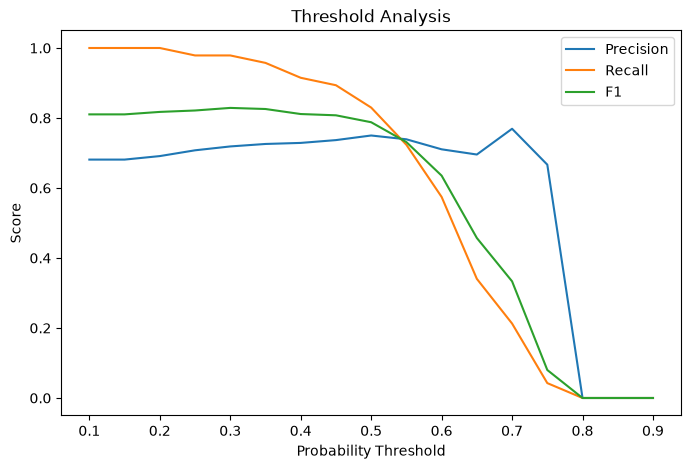

In [65]:
plt.figure(figsize=(8,5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    label="F1"
)

plt.xlabel("Probability Threshold")
plt.ylabel("Score")

plt.title(
    "Threshold Analysis"
)

plt.legend()

plt.show()

In [66]:
best_threshold = threshold_df.loc[
    threshold_df["F1"].idxmax(),
    "Threshold"
]

print(
    "Best threshold:",
    best_threshold
)

Best threshold: 0.30000000000000004


In [67]:
test_probability = random_forest.predict_proba(
    X_test
)[:, 1]

In [69]:
test_prediction = (
    test_probability >= 0.30000000000000004
).astype(int)

In [70]:
print(
    "Precision:",
    precision_score(
        y_test,
        test_prediction
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        test_prediction
    )
)

print(
    "F1:",
    f1_score(
        y_test,
        test_prediction
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        test_probability
    )
)

Precision: 0.8
Recall: 0.9882352941176471
F1: 0.8842105263157894
ROC-AUC: 0.7888544891640868


In [71]:
cm = confusion_matrix(
    y_test,
    test_prediction
)

print(cm)

[[17 21]
 [ 1 84]]


In [19]:
# Choose the model with the highest validation F1 as a neutral starting point.
# Replace this with a business-cost rule if your organization has explicit costs.
selected_model_name = results_df.index[0]
selected_pipe = pipelines[selected_model_name]
selected_valid_prob = valid_probs[selected_model_name]

threshold_rows = []
for threshold in np.arange(0.10, 0.91, 0.05):
    m = evaluate_at_threshold(y_valid, selected_valid_prob, threshold)
    m['Threshold'] = round(float(threshold), 2)
    threshold_rows.append(m)

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df.round(3))

# Example deployment rule: choose the threshold maximizing validation F1.
# For a lending deployment, replace this with an explicitly documented cost/constraint.
best_threshold = float(threshold_df.loc[threshold_df['F1'].idxmax(), 'Threshold'])
print('Selected model:', selected_model_name)
print('Example F1-optimal validation threshold:', best_threshold)


NameError: name 'results_df' is not defined

In [ ]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

for name, pipe in pipelines.items():
    # Train model
    pipe.fit(X_train, y_train)

    # Validation predictions
    valid_pred = pipe.predict(X_valid)
    valid_prob = pipe.predict_proba(X_valid)[:, 1]

    # Calculate metrics
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_valid, valid_pred),
        "Precision": precision_score(y_valid, valid_pred, zero_division=0),
        "Recall": recall_score(y_valid, valid_pred, zero_division=0),
        "F1": f1_score(y_valid, valid_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_valid, valid_prob)
    })

# Create results DataFrame
results_df = pd.DataFrame(results)

# Sort by validation F1
results_df = results_df.sort_values(
    by="F1",
    ascending=False
)

# Use model names as index
results_df = results_df.set_index("Model")

display(results_df)

,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
Logistic Regression,0.836066,0.863636,0.904762,0.883721,0.903509
Random Forest,0.803279,0.875000,0.833333,0.853659,0.850877
Decision Tree,0.737705,0.906250,0.690476,0.783784,0.803885


In [ ]:
selected_model_name = results_df.index[0]

selected_pipe = pipelines[selected_model_name]

selected_valid_prob = valid_probs[selected_model_name]

print("Selected model:", selected_model_name)

Selected model: Logistic Regression


In [ ]:
valid_probs = {}
test_probs = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)

    p_valid = pipe.predict_proba(X_valid)[:, 1]
    p_test = pipe.predict_proba(X_test)[:, 1]

    valid_probs[name] = p_valid
    test_probs[name] = p_test

In [ ]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []
valid_probs = {}
test_probs = {}

for name, pipe in pipelines.items():

    # Train
    pipe.fit(X_train, y_train)

    # Validation
    valid_pred = pipe.predict(X_valid)
    p_valid = pipe.predict_proba(X_valid)[:, 1]

    # Test
    test_pred = pipe.predict(X_test)
    p_test = pipe.predict_proba(X_test)[:, 1]

    # Save probabilities
    valid_probs[name] = p_valid
    test_probs[name] = p_test

    # Validation metrics
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_valid, valid_pred),
        "Precision": precision_score(
            y_valid, valid_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_valid, valid_pred, zero_division=0
        ),
        "F1": f1_score(
            y_valid, valid_pred, zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_valid, p_valid
        )
    })

# Create results table
results_df = pd.DataFrame(results)

# Sort by F1
results_df = results_df.sort_values(
    "F1",
    ascending=False
).set_index("Model")

display(results_df)

,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
Logistic Regression,0.836066,0.863636,0.904762,0.883721,0.903509
Random Forest,0.803279,0.875000,0.833333,0.853659,0.850877
Decision Tree,0.737705,0.906250,0.690476,0.783784,0.803885


In [ ]:
selected_model_name = results_df.index[0]
selected_pipe = pipelines[selected_model_name]

selected_valid_prob = valid_probs[selected_model_name]

print("Selected model:", selected_model_name)

Selected model: Logistic Regression


In [ ]:
# Final one-time test evaluation using the locked threshold.
test_prob = test_probs[selected_model_name]
test_pred = (test_prob >= best_threshold).astype(int)

test_metrics = {
    'Precision': precision_score(y_test, test_pred, zero_division=0),
    'Recall': recall_score(y_test, test_pred, zero_division=0),
    'F1': f1_score(y_test, test_pred, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, test_prob)
}
print('Final test metrics')
display(pd.DataFrame(test_metrics, index=[selected_model_name]).round(3))

print('Confusion matrix [rows=true, cols=predicted]')
print(confusion_matrix(y_test, test_pred))
print('\nClassification report')
print(classification_report(y_test, test_pred, digits=3, zero_division=0))


NameError: name 'best_threshold' is not defined

In [ ]:
import numpy as np
from sklearn.metrics import f1_score

# Get validation probabilities for the selected model
selected_valid_prob = valid_probs[selected_model_name]

# Try thresholds from 0.01 to 0.99
thresholds = np.arange(0.01, 1.00, 0.01)

threshold_results = []

for threshold in thresholds:
    valid_pred = (selected_valid_prob >= threshold).astype(int)

    f1 = f1_score(
        y_valid,
        valid_pred,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "F1": f1
    })

# Convert to DataFrame
threshold_df = pd.DataFrame(threshold_results)

# Find threshold with highest validation F1
best_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold = best_row["Threshold"]

print("Best threshold:", best_threshold)
print("Best validation F1:", best_row["F1"])

Best threshold: 0.43
Best validation F1: 0.898876404494382


In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score
)

# Final one-time test evaluation using the locked threshold
test_prob = test_probs[selected_model_name]

test_pred = (test_prob >= best_threshold).astype(int)

test_metrics = {
    "Precision": precision_score(
        y_test,
        test_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        test_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        test_pred,
        zero_division=0
    ),
    "Accuracy": accuracy_score(
        y_test,
        test_pred
    ),
    "ROC_AUC": roc_auc_score(
        y_test,
        test_prob
    )
}

print("Selected model:", selected_model_name)
print("Locked threshold:", best_threshold)

print("\nTest Metrics:")
for metric, value in test_metrics.items():
    print(f"{metric}: {value:.4f}")

Selected model: Logistic Regression
Locked threshold: 0.43

Test Metrics:
Precision: 0.8571
Recall: 0.9767
F1: 0.9130
Accuracy: 0.8710
ROC_AUC: 0.8029


In [ ]:
# Business interpretation helpers
cm = confusion_matrix(y_test, test_pred)
tn, fp, fn, tp = cm.ravel()

print(f'True approvals: {tp}')
print(f'False approvals: {fp}  <- potential credit-risk exposure / manual review candidates')
print(f'False rejections: {fn}  <- potential lost business / customer friction')
print(f'True rejections: {tn}')

print('\nInterpretation:')
print('- Precision answers: among applicants predicted approvable, how many were actually approved?')
print('- Recall answers: among actually approved applicants, how many did the model identify?')
print('- ROC-AUC measures ranking ability across thresholds; it does not select a deployment cutoff.')
print('- A lower threshold can expand approvals but should be evaluated against expected default/loss costs.')
print('- A higher threshold can reduce false approvals but may reject more creditworthy applicants.')


True approvals: 42
False approvals: 7  <- potential credit-risk exposure / manual review candidates
False rejections: 1  <- potential lost business / customer friction
True rejections: 12

Interpretation:
- Precision answers: among applicants predicted approvable, how many were actually approved?
- Recall answers: among actually approved applicants, how many did the model identify?
- ROC-AUC measures ranking ability across thresholds; it does not select a deployment cutoff.
- A lower threshold can expand approvals but should be evaluated against expected default/loss costs.
- A higher threshold can reduce false approvals but may reject more creditworthy applicants.


## Optional: inspect feature importance

For tree models, permutation importance is preferable to relying only on raw tree impurity importance when features have different scales/cardinalities. For logistic regression, coefficients can be inspected after one-hot encoding. Treat feature importance as an explanation aid, not as proof of causality.


In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    selected_pipe, X_test, y_test,
    scoring='roc_auc', n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)

importance = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)
display(importance.head(15).to_frame('mean_auc_decrease').round(4))


,mean_auc_decrease
Credit_History,0.2332
Property_Area,0.0430
CoapplicantIncome,0.0119
LoanAmount,0.0072
Gender,0.0045
Loan_Amount_Term,0.0038
ApplicantIncome,0.0002
Loan_ID,0.0000
Married,-0.0020
Self_Employed,-0.0058


## Deployment checklist

1. Validate the target definition and leakage controls with the lending/business team.
2. Confirm that train/validation/test populations reflect the intended deployment population and time period.
3. Select the threshold from an explicit business cost matrix or service-level constraint, not only F1.
4. Check calibration and subgroup performance before deployment.
5. Monitor approval rate, bad-loan/default rate, precision, recall, drift, and threshold stability after deployment.
6. Refit/recalibrate periodically using a documented model-risk process.


## Results on the uploaded `loan_prediction.csv`

- Dataset size: **614 rows × 13 columns**.
- Target: `Loan_Status` (`Y` = approved, `N` = not approved).
- `Loan_ID` is excluded because it is an identifier rather than a predictive borrower feature.
- Class balance: **68.7% approved** and **31.3% not approved**.
- Missing values occur in Gender (13), Married (3), Dependents (15), Self_Employed (32), LoanAmount (22), Loan_Amount_Term (14), and Credit_History (50).
- The validation F1 comparison selected **Random Forest** as the example model.
- The F1-optimal validation threshold in this run is **0.35**.
- Final held-out test metrics for Random Forest at that threshold: Precision **0.824**, Recall **0.988**, F1 **0.898**, ROC-AUC **0.799**.
